# Trabajo Práctico — Series Temporales

## 03 — Análisis Exploratorio (EDA)

**Objetivo de este notebook:** explorar visual y estadísticamente las tres series ya limpias (`data/processed/serie_california.csv`) antes de modelar: forma de cada serie, estacionalidad, autocorrelación, y una primera intuición de estacionariedad (que se formaliza recién en `04_estacionariedad.ipynb` con los tests correspondientes).

**Series:** ozono troposférico (ppm), temperatura (°C) y radiación solar GHI (W/m2), las tres horarias en UTC, estación Los Ángeles / LAX, 1998-2025.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

datos = pd.read_csv(
    PROJECT_ROOT / "data/processed/serie_california.csv",
    index_col="datetime_utc",
    parse_dates=True,
)
print(f"Directorio raíz del proyecto detectado: {PROJECT_ROOT}")
print(f"Filas: {len(datos):,} | Columnas: {list(datos.columns)}")
print(f"Rango: {datos.index.min()} -> {datos.index.max()}")

Directorio raíz del proyecto detectado: C:\Series_AMBA
Filas: 239,078 | Columnas: ['ozono_ppm', 'temperatura_c', 'radiacion_ghi_wm2']
Rango: 1998-01-01 08:00:00+00:00 -> 2025-08-27 09:00:00+00:00


## 1. Estadística descriptiva

Antes de graficar nada: chequear tipos, faltantes y algunos estadísticos básicos de cada serie.

In [2]:
print(datos.dtypes)
print()
print(datos.isna().sum())
print()
datos.describe()

ozono_ppm            float64
temperatura_c        float64
radiacion_ghi_wm2    float64
dtype: object

ozono_ppm            0
temperatura_c        0
radiacion_ghi_wm2    0
dtype: int64



,ozono_ppm,temperatura_c,radiacion_ghi_wm2
count,239078.000000,239078.000000,239078.000000
mean,0.021473,17.081963,225.006826
std,0.018586,3.999925,309.066924
min,0.000000,1.700000,0.000000
25%,0.004000,14.400000,0.000000
50%,0.019000,17.100000,13.000000
75%,0.034000,19.400000,429.000000
max,0.185000,39.400000,1065.000000


## 2. Series crudas

Se grafica cada variable completa (1998-2025) y también un recorte de un mes para ver el detalle horario (a escala completa, el ciclo diario de ozono/radiación se aplasta visualmente).

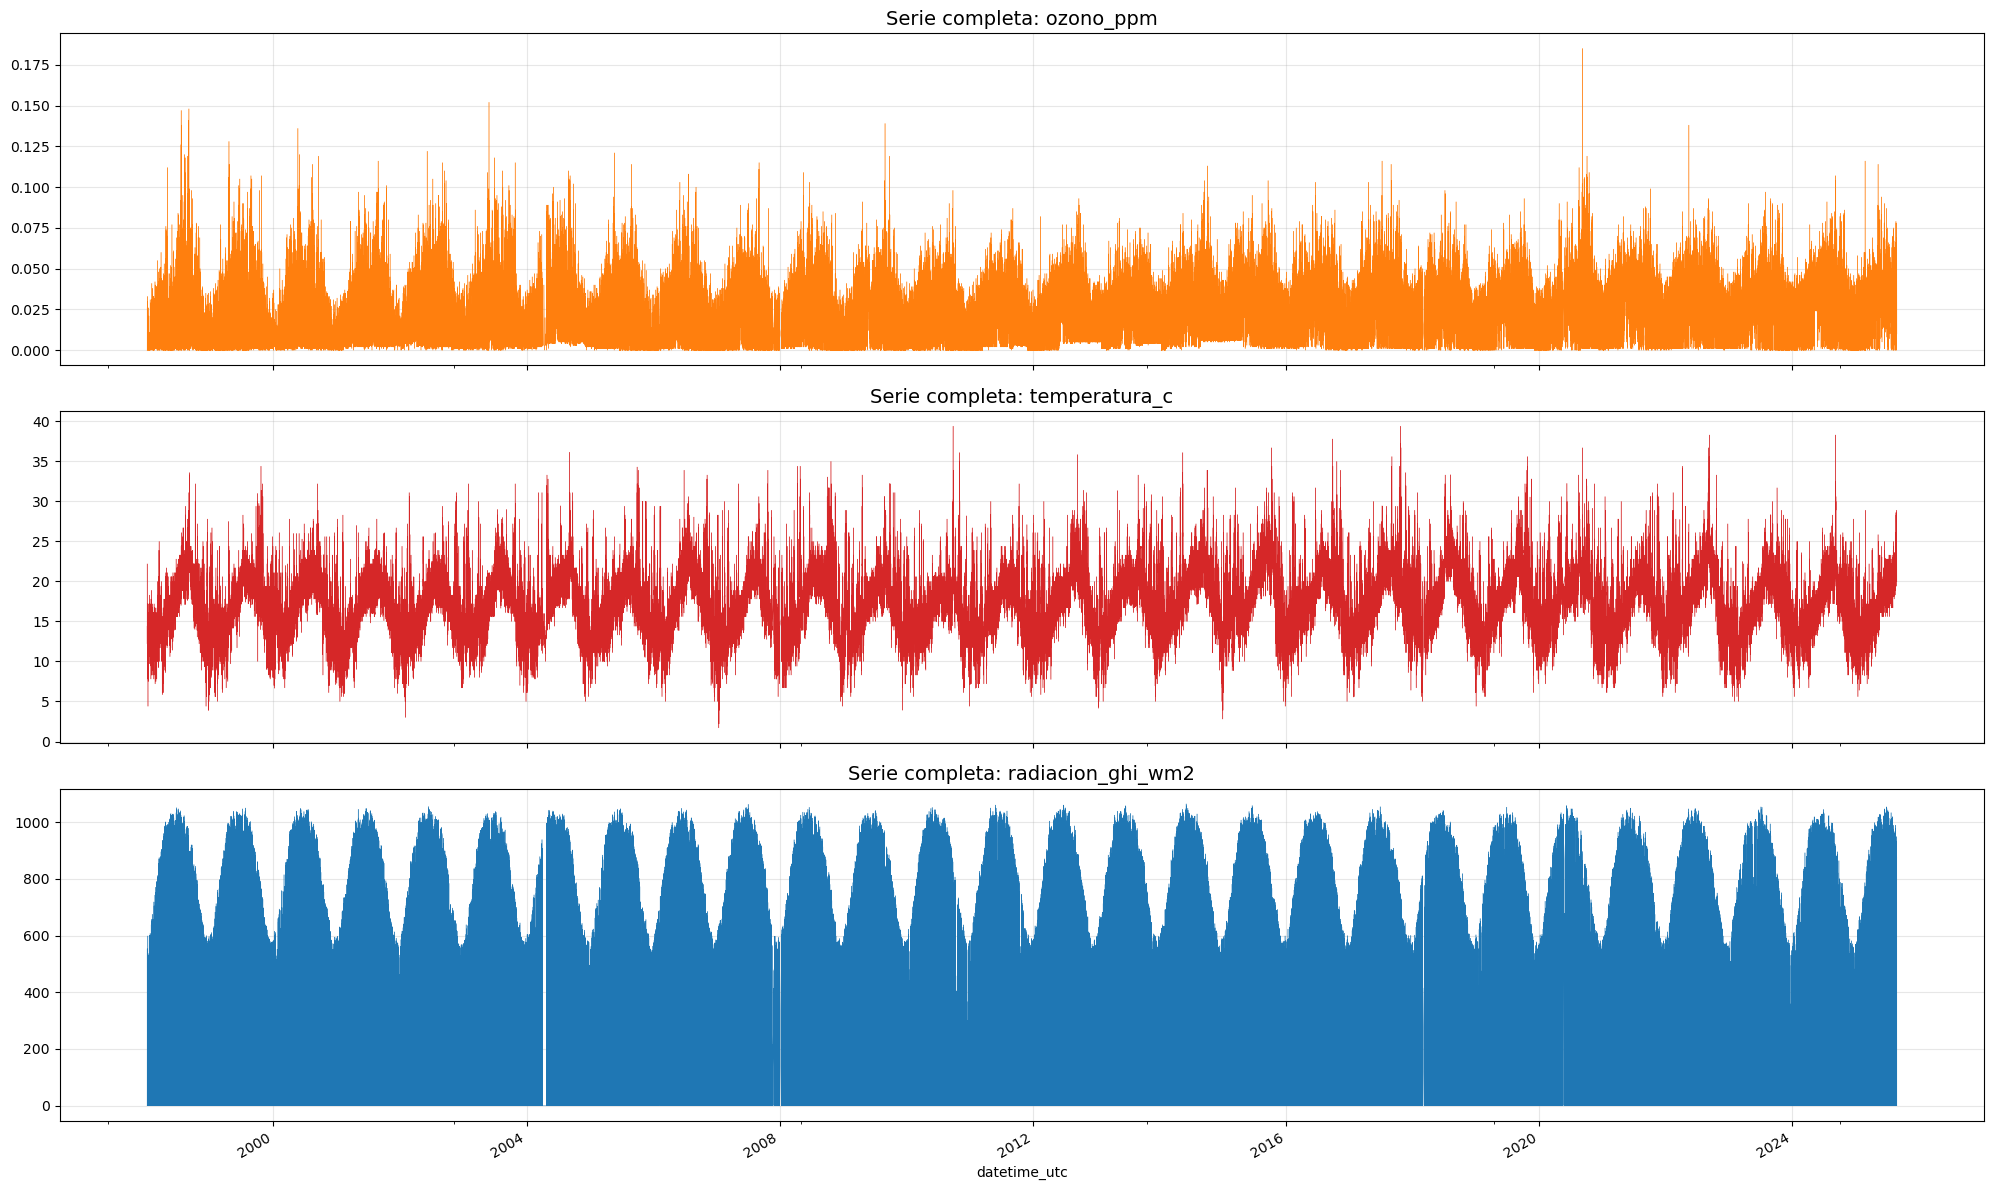

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(20, 12), sharex=True)
for ax, col, color in zip(axes, datos.columns, ["tab:orange", "tab:red", "tab:blue"]):
    datos[col].plot(ax=ax, color=color, linewidth=0.3)
    ax.set_title(f"Serie completa: {col}", size=14)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

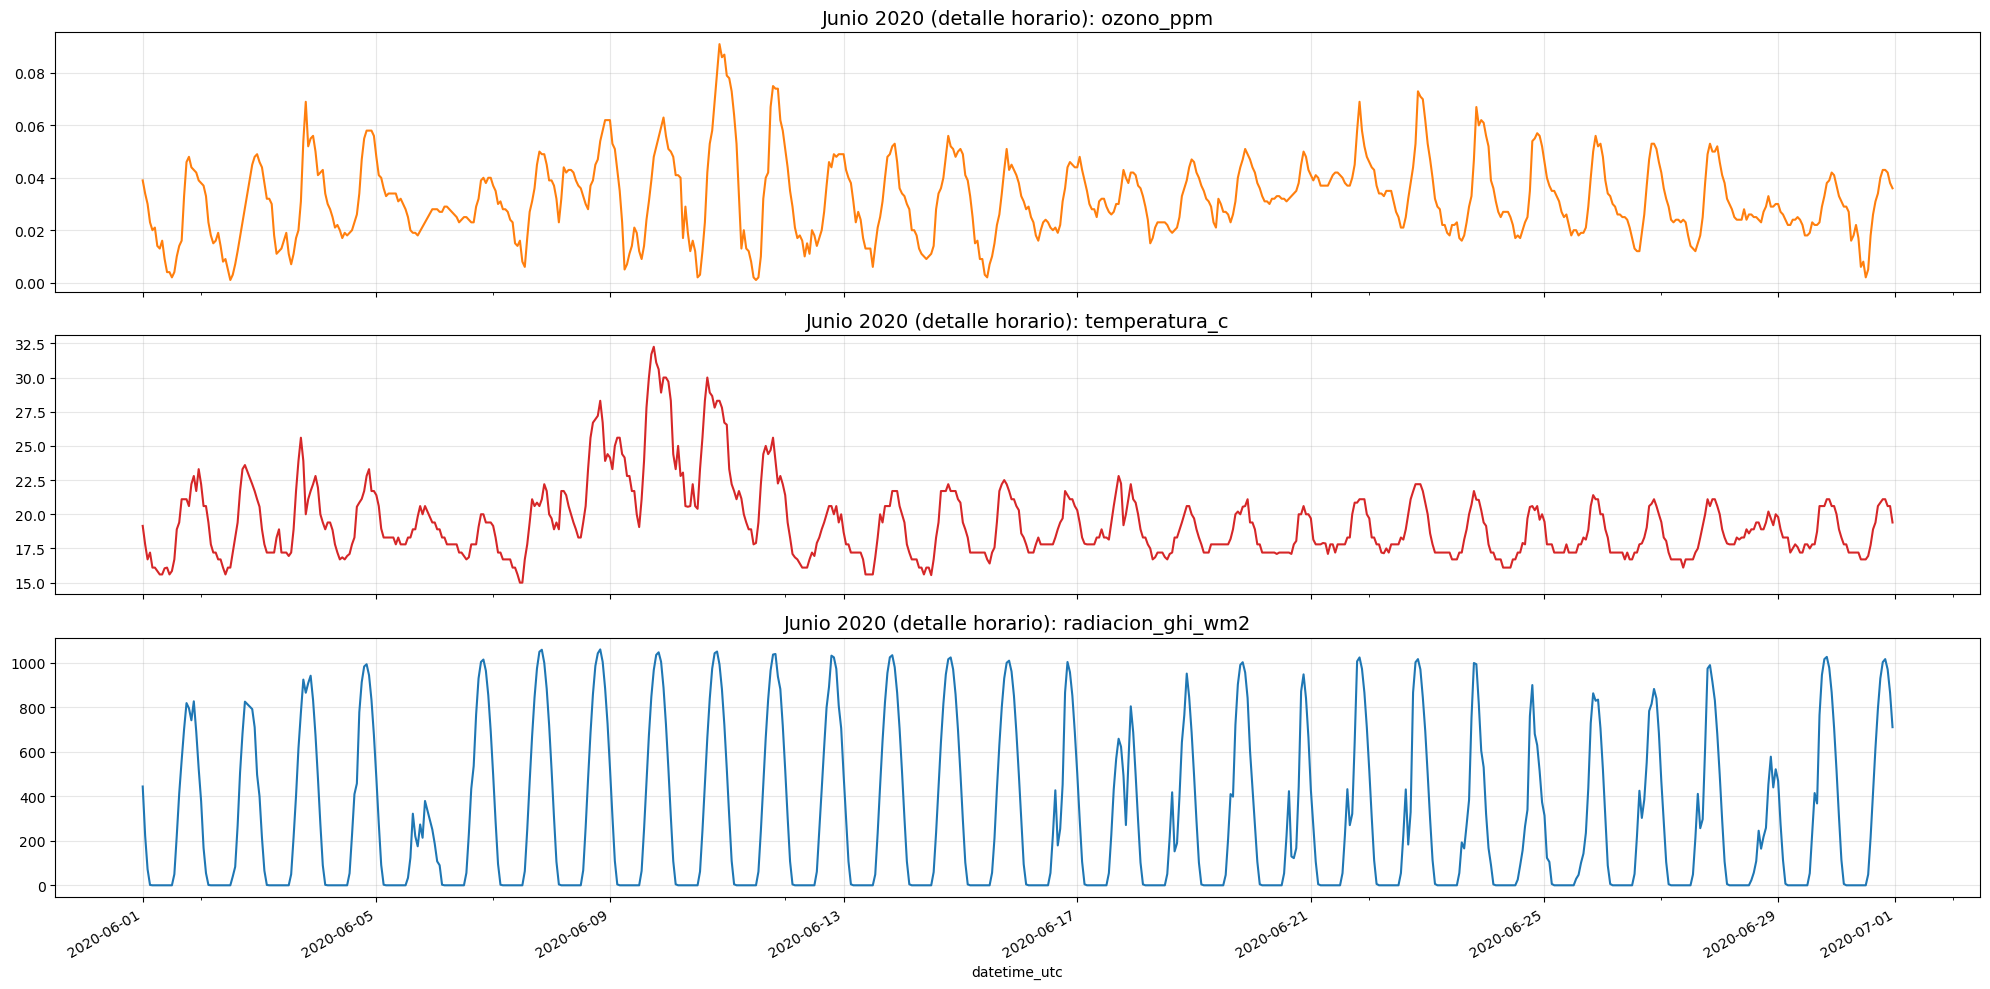

In [4]:
recorte = datos.loc["2020-06-01":"2020-06-30"]

fig, axes = plt.subplots(3, 1, figsize=(20, 10), sharex=True)
for ax, col, color in zip(axes, recorte.columns, ["tab:orange", "tab:red", "tab:blue"]):
    recorte[col].plot(ax=ax, color=color)
    ax.set_title(f"Junio 2020 (detalle horario): {col}", size=14)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Descomposición estacional

Con datos horarios, el ciclo dominante es el **diario** (`period=24`): ozono y radiación solar suben de día y bajan de noche por razones físicas directas (fotoquímica solar, radiación misma). Se descompone cada serie en tendencia + estacionalidad + residuo con `seasonal_decompose`, comparando modelo aditivo y multiplicativo.

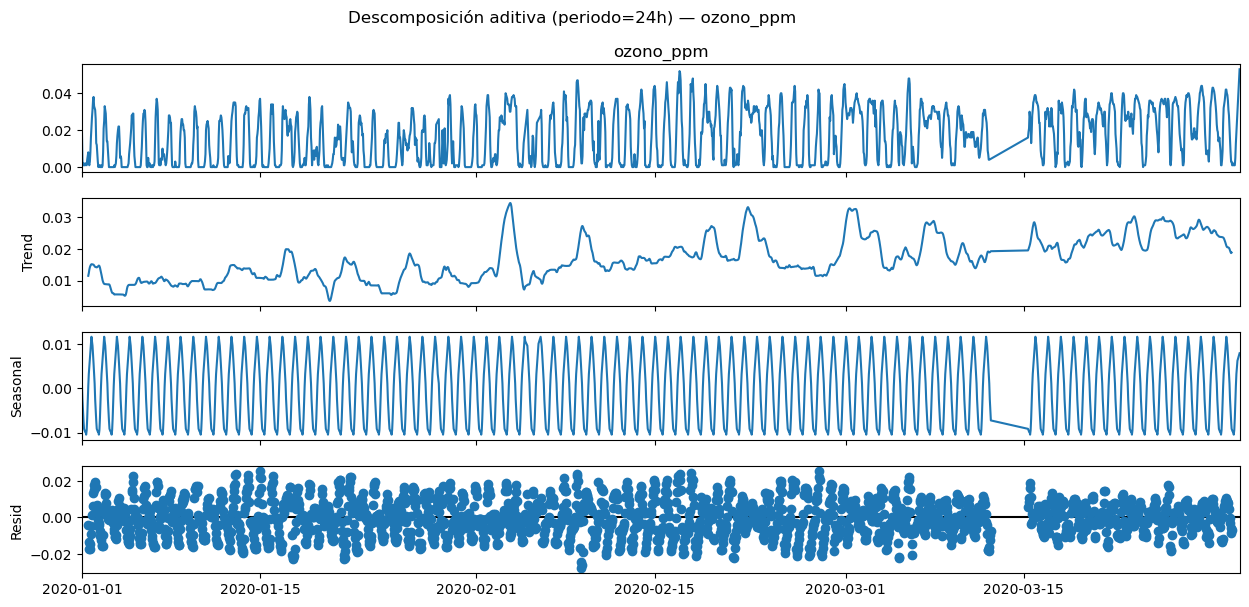

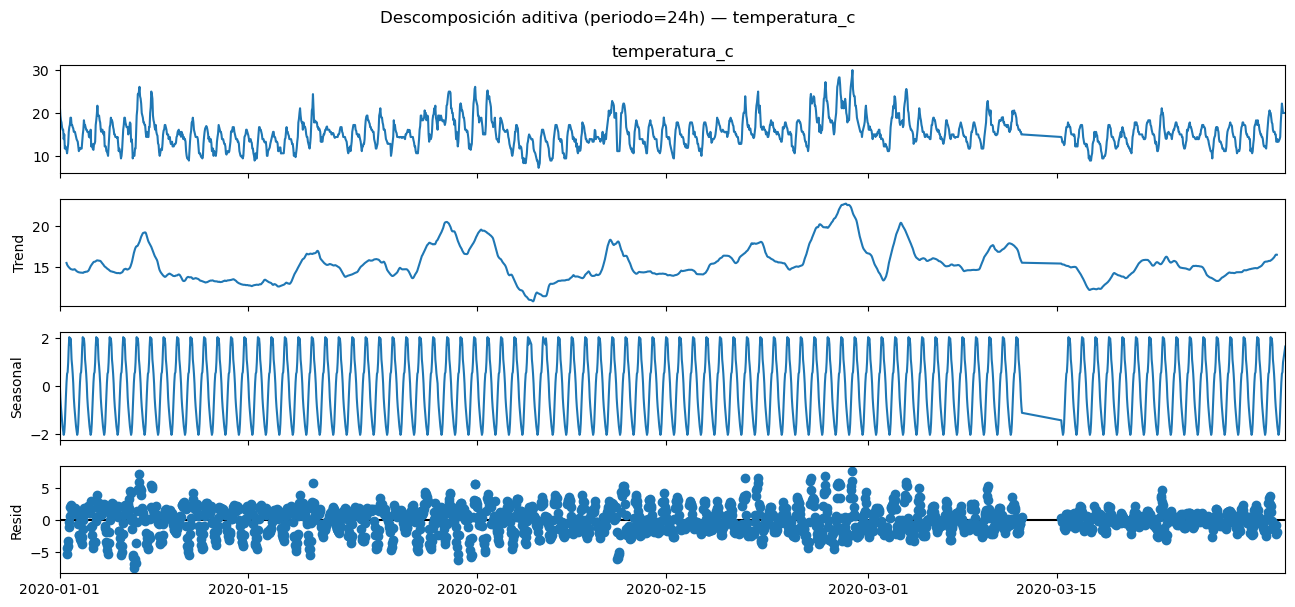

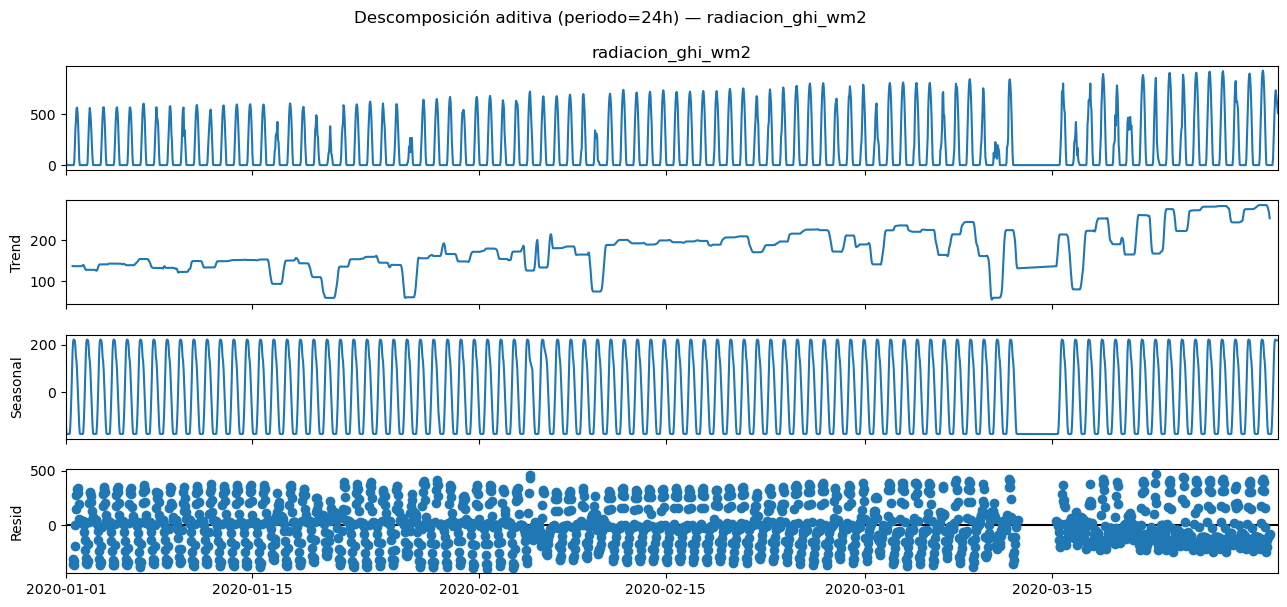

In [5]:
PERIODO_DIARIO = 24
ventana_decompose = datos.loc["2020-01-01":"2020-03-31"]  # recorte: decompose sobre 9M de filas es innecesario y lento

resultados_decompose = {}
for col in datos.columns:
    resultados_decompose[col] = {
        "additive": seasonal_decompose(ventana_decompose[col], model="additive", period=PERIODO_DIARIO),
        "multiplicative": seasonal_decompose(ventana_decompose[col].clip(lower=0.01), model="multiplicative", period=PERIODO_DIARIO),
    }

for col in datos.columns:
    fig = resultados_decompose[col]["additive"].plot()
    fig.set_size_inches(14, 6)
    fig.suptitle(f"Descomposición aditiva (periodo=24h) — {col}", y=1.02)
    plt.show()

## 4. Autocorrelación (ACF/PACF)

Se grafica la ACF sobre un recorte reciente (usar los ~230.000 registros completos no aporta más señal visual y es mucho más lento de graficar). Se espera ver el patrón de "dientes de sierra" cada 24 lags, marca típica de estacionalidad diaria.

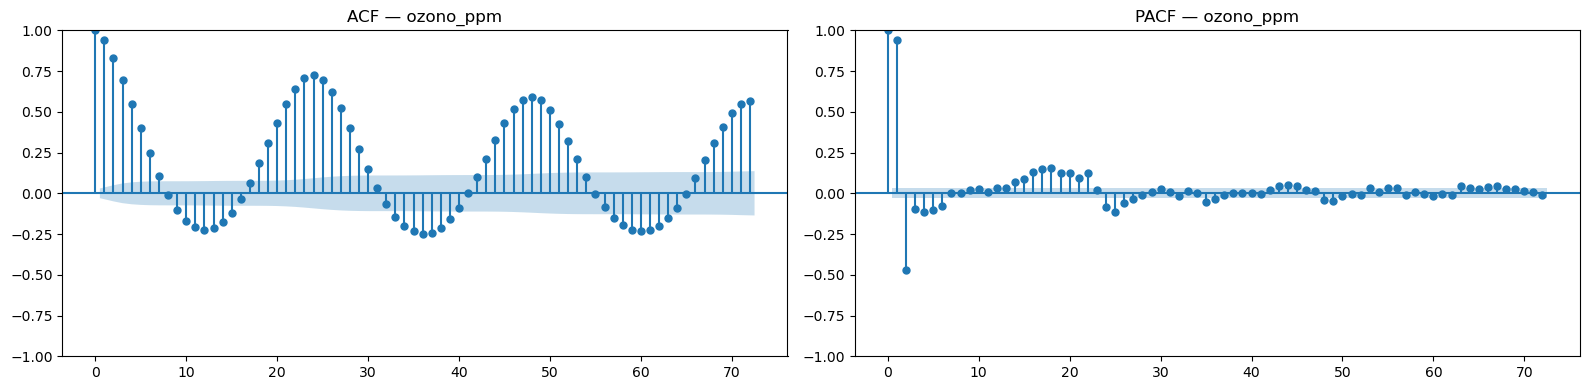

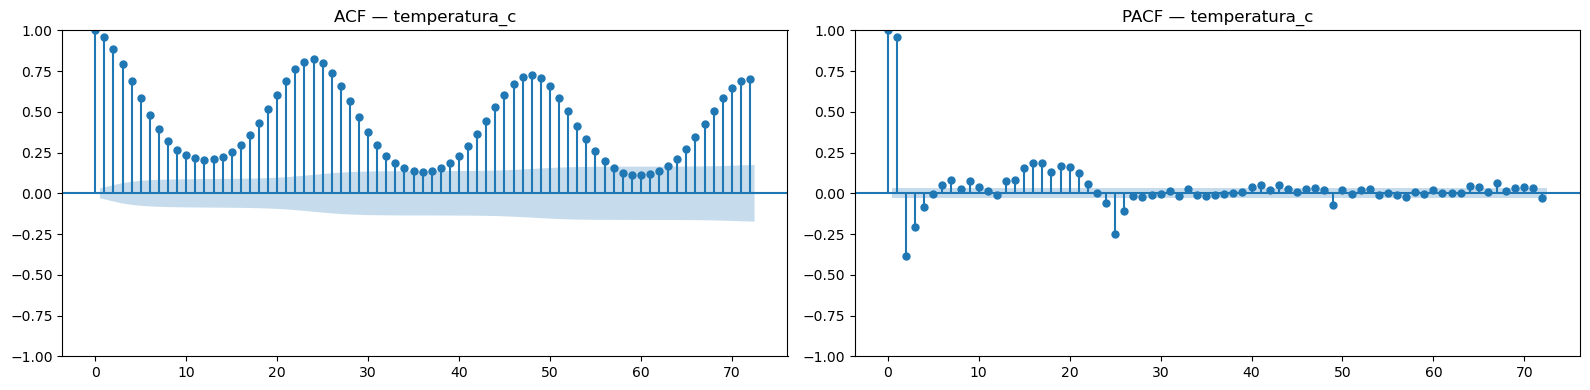

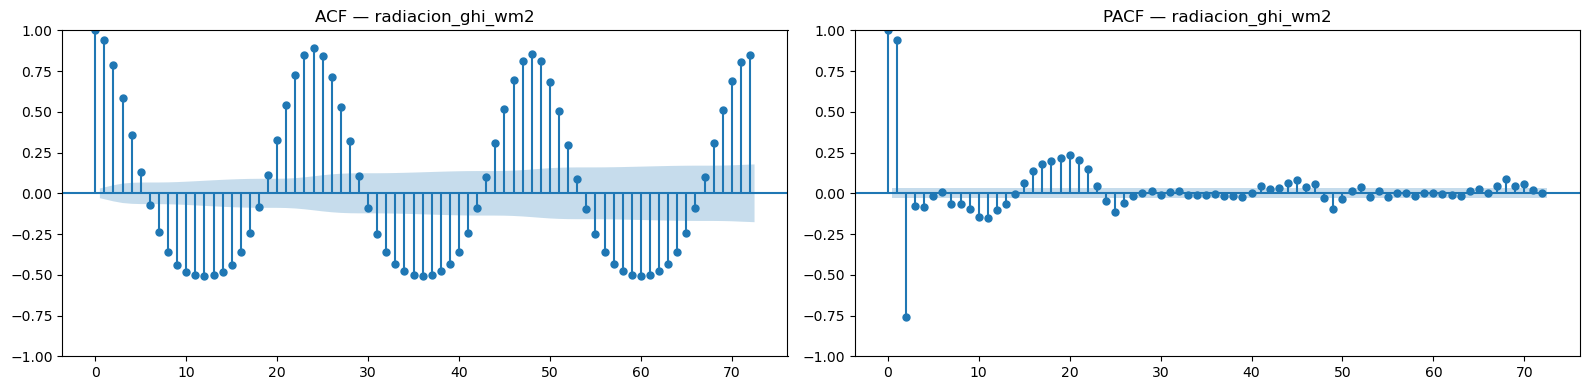

In [6]:
ventana_acf = datos.loc["2023-01-01":"2023-06-30"]

for col in datos.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    plot_acf(ventana_acf[col], lags=72, ax=axes[0])
    axes[0].set_title(f"ACF — {col}")
    plot_pacf(ventana_acf[col], lags=72, ax=axes[1], method="ywm")
    axes[1].set_title(f"PACF — {col}")
    plt.tight_layout()
    plt.show()

## 5. Primera diferencia y diferencia estacional

Se compara la serie original contra su primera diferencia (`.diff()`, quita tendencia) y contra su diferencia estacional (`.diff(24)`, quita el ciclo diario), mirando cómo cambia la ACF en cada caso. Esto es exploratorio nomás — la decisión formal de cuánto diferenciar (`d`, `D`) se toma en `04_estacionariedad.ipynb` con tests de raíz unitaria, no a ojo.

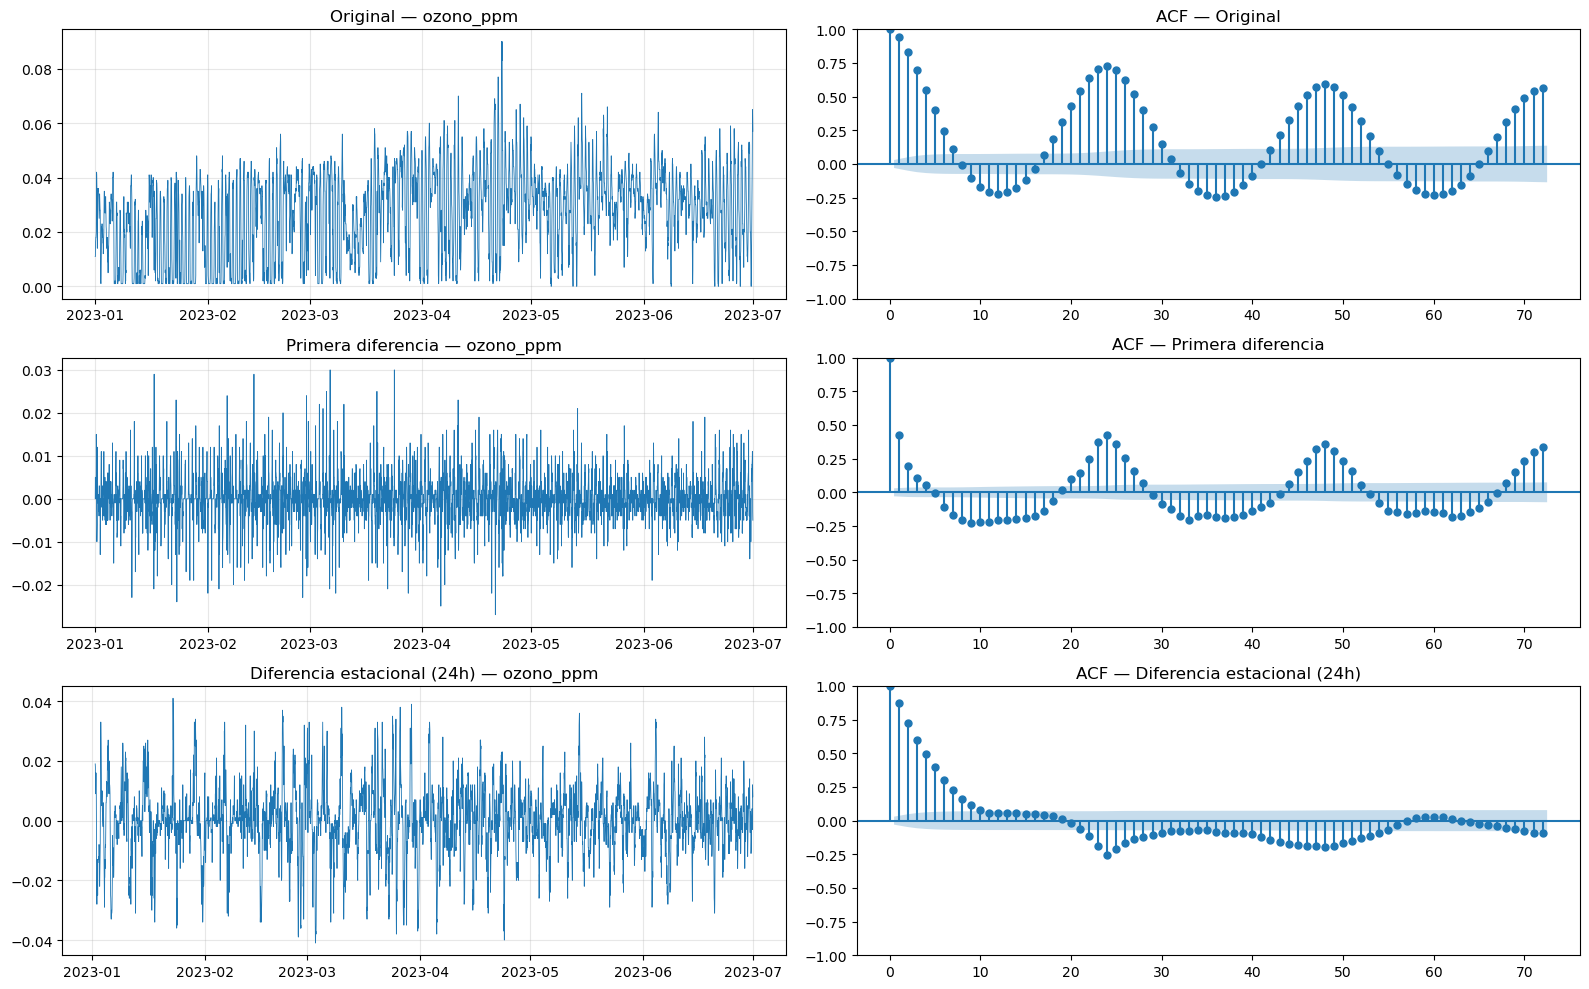

In [7]:
col_ejemplo = "ozono_ppm"
serie_ejemplo = ventana_acf[col_ejemplo]

diferenciada = serie_ejemplo.diff().dropna()
diferenciada_estacional = serie_ejemplo.diff(24).dropna()

fig, axes = plt.subplots(3, 2, figsize=(16, 10))
for fila, (nombre, serie) in enumerate([
    ("Original", serie_ejemplo),
    ("Primera diferencia", diferenciada),
    ("Diferencia estacional (24h)", diferenciada_estacional),
]):
    axes[fila, 0].plot(serie, linewidth=0.6)
    axes[fila, 0].set_title(f"{nombre} — {col_ejemplo}")
    axes[fila, 0].grid(True, alpha=0.3)
    plot_acf(serie, lags=72, ax=axes[fila, 1])
    axes[fila, 1].set_title(f"ACF — {nombre}")
plt.tight_layout()
plt.show()

## 6. Comparación con ruido blanco y random walk

Como referencia teórica: ¿qué tan lejos está cada una de nuestras series de un ruido blanco puro o de un paseo aleatorio? Se simulan ambos con la misma cantidad de observaciones que la ventana usada arriba, y se compara la forma de la ACF.

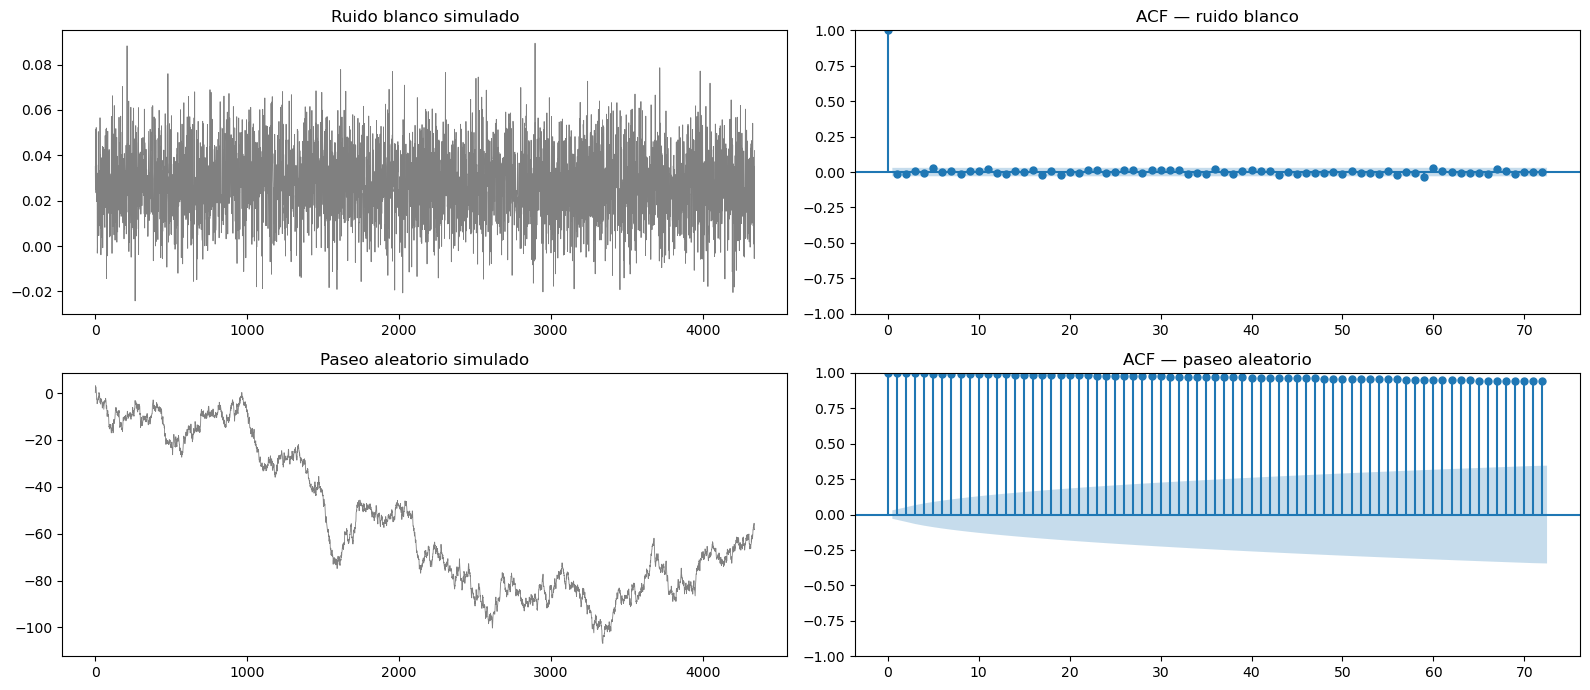

In [8]:
np.random.seed(42)
n = len(serie_ejemplo)

ruido_blanco = pd.Series(np.random.normal(loc=serie_ejemplo.mean(), scale=serie_ejemplo.std(), size=n))
paseo_aleatorio = pd.Series(np.cumsum(np.random.standard_normal(n)))

fig, axes = plt.subplots(2, 2, figsize=(16, 7))
axes[0, 0].plot(ruido_blanco, linewidth=0.6, color="gray")
axes[0, 0].set_title("Ruido blanco simulado")
plot_acf(ruido_blanco, lags=72, ax=axes[0, 1])
axes[0, 1].set_title("ACF — ruido blanco")

axes[1, 0].plot(paseo_aleatorio, linewidth=0.6, color="gray")
axes[1, 0].set_title("Paseo aleatorio simulado")
plot_acf(paseo_aleatorio, lags=72, ax=axes[1, 1])
axes[1, 1].set_title("ACF — paseo aleatorio")
plt.tight_layout()
plt.show()

**Lectura esperada:** el ruido blanco no tiene autocorrelación significativa en ningún lag (todas las barras dentro de la banda de confianza). El paseo aleatorio tiene una ACF que decae muy lentamente (no estacionario por definición). Nuestras series reales, en cambio, muestran el patrón periódico de 24 horas — ni ruido blanco ni paseo aleatorio puro, sino una serie con estacionalidad fuerte que va a requerir diferenciación estacional además de (o en vez de) la regular.

**Proyecto listo para continuar con `04_estacionariedad.ipynb`** (tests formales de raíz unitaria y determinación de `d` y `D`).